In [2]:
%reload_ext autoreload
%autoreload 2

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from tqdm import tqdm
from cartopy import crs as ccrs

from nzdownscale.dataprocess.config_local import DATA_PATHS
from nzdownscale.dataprocess.config import VAR_ERA5, VAR_STATIONS
from nzdownscale.dataprocess import era5, stations, wrf

In [91]:
var = 'surface_pressure'
year = np.arange(2009, 2012)

# Load ERA5

In [92]:
process_era5 = era5.ProcessERA5()
era5_var = VAR_ERA5[var]['var_name']
era5_ds = process_era5.load_ds(var, year)
era5_ds = era5_ds.compute() / 100 # Pa to hPa

# Load stations

In [93]:
process_stations = stations.ProcessStations()
station_var = VAR_STATIONS[var]['var_name']
station_df = process_stations.load_stations(var, year)

Filtering stations: 100%|██████████| 170/170 [00:06<00:00, 26.03it/s]


Concatenating stations into pd.DataFrame


In [85]:
# station_df_nonan = station_df.dropna().reset_index()
# df = station_df_nonan
# # Assuming you have a DataFrame named df with 'time' and 'station_name' columns
# # Convert 'time' column to datetime if it's not already in datetime format
# df['time'] = pd.to_datetime(df['time'])

# # Extract year from the 'time' column
# df['year'] = df['time'].dt.year

# # Group by 'year' and 'station_name', then count the occurrences
# df_station_counts = df.groupby(['year', 'station_name']).size().reset_index(name='count')

# # Display the DataFrame
# with pd.option_context('display.max_rows', None):
#     print(df_station_counts)

,time,station_name,latitude,longitude,stn_lev_pres
0,2000-01-01 02:00:00,WAIOURU AWS,-39.47200,175.68200,914.1
1,2000-01-01 05:00:00,WAIOURU AWS,-39.47200,175.68200,913.2
2,2000-01-01 08:00:00,WAIOURU AWS,-39.47200,175.68200,914.0
3,2000-01-01 11:00:00,WAIOURU AWS,-39.47200,175.68200,914.5
4,2000-01-01 14:00:00,WAIOURU AWS,-39.47200,175.68200,913.9
...,...,...,...,...,...
1534125,2011-12-31 00:00:00,WHAKATANE AERO AWS,-37.92478,176.91857,1007.8
1534126,2011-12-31 00:00:00,WHANGANUI AERO AWS,-39.96122,175.02581,1007.4
1534127,2011-12-31 00:00:00,WHANGAPARAOA AWS,-36.60268,174.83458,993.4
1534128,2011-12-31 00:00:00,WHANGAREI AERO AWS,-35.77062,174.36285,999.7


In [47]:
len_df = len(station_df)
# station_df = station_df.dropna(subset=[station_var])
# print(f'Dropped {len_df - len(station_df)} NaN values')
station_df

stn_lev_pres
time       station_name        latitude  longitude              
2000-01-01 AUCKLAND AERO       -37.00813 174.78873           NaN
           BARING HEAD         -41.40828 174.87146           NaN
           BLENHEIM AERO       -41.52000 173.87200           NaN
           BLENHEIM AERO AWS   -41.52135 173.86432           NaN
           BROTHERS ISLAND AWS -41.10330 174.44174           NaN
...                                                          ...
2005-12-31 WHANGANUI AERO AWS  -39.96122 175.02581           NaN
           WHANGAPARAOA AWS    -36.60268 174.83458           NaN
           WHANGAREI AERO      -35.76955 174.36028           NaN
           WHANGAREI AERO AWS  -35.77062 174.36285           NaN
           WHITIANGA AERO AWS  -36.83237 175.67542           NaN

[3789682 rows x 1 columns]

# Plots

In [8]:
era5_mean = float(era5_ds[era5_var].mean(dim=['time', 'latitude', 'longitude']).values)
station_mean = np.mean(station_df[station_var].values)
print(f'ERA5 overall mean: {era5_mean}, \nStation overall mean: {station_mean}')

ERA5 overall mean: 960.1135864257812, 
Station overall mean: nan


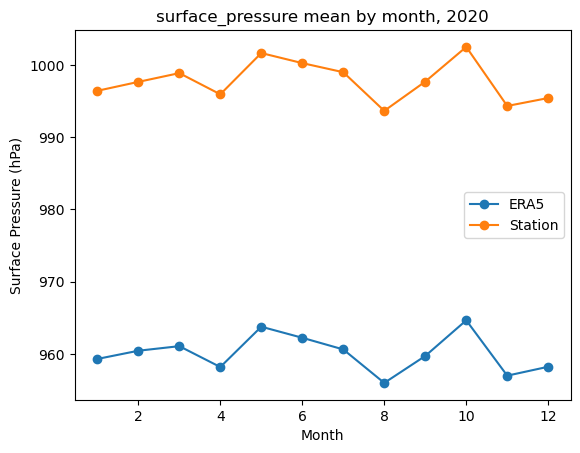

In [9]:
era5_mean_by_month = era5_ds[era5_var].groupby('time.month').mean(dim=['time', 'latitude', 'longitude']).values

station_df_reset = station_df.reset_index()
station_df_reset['time'] = pd.to_datetime(station_df_reset['time'])
station_df_reset = station_df_reset.set_index('time')
station_mean_by_month = station_df_reset[station_var].resample('ME').mean().values

fig, ax = plt.subplots()
ax.plot(np.arange(1, 13), era5_mean_by_month, label='ERA5', marker='o')
ax.plot(np.arange(1, 13), station_mean_by_month, label='Station', marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('Surface Pressure (hPa)')
ax.legend()
ax.set_title(f'{var} mean by month, {year}')
plt.show();

# By station

In [10]:
stations = station_df_reset['station_name'].unique()

In [11]:
stats_by_station = {}
for station in tqdm(stations):
    station_data = station_df_reset[station_df_reset['station_name'] == station]
    station_data_vals = station_data[station_var]
    station_mean = station_data_vals.mean()
    station_std = station_data_vals.std()

    era5_data = era5_ds[era5_var].sel(latitude=station_data['latitude'].unique()[0],
                                       longitude=station_data['longitude'].unique()[0],
                                       method='nearest')
    era5_data_vals = era5_data.values
    era5_mean = era5_data_vals.mean()
    era5_std = era5_data_vals.std()

    stats_by_station[station] = {'station_mean': station_mean, 
                                 'station_std': station_std,
                                 'era5_mean': era5_mean,
                                 'era5_std': era5_std}

100%|██████████| 212/212 [00:22<00:00,  9.27it/s]


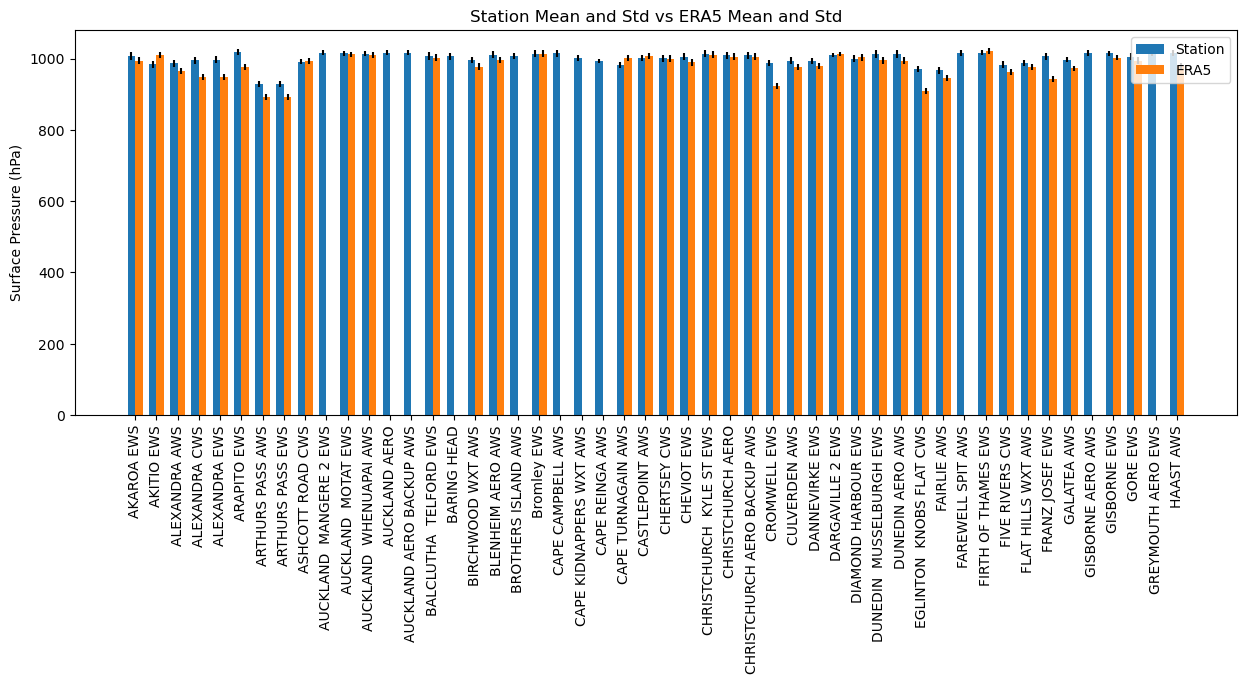

In [12]:
num_stations = len(stats_by_station)

station_names = list(stats_by_station.keys())

station_means = [stats_by_station[station]['station_mean'] for station in station_names]
station_stds = [stats_by_station[station]['station_std'] for station in station_names]

era5_means = [stats_by_station[station]['era5_mean'] for station in station_names]
era5_stds = [stats_by_station[station]['era5_std'] for station in station_names]

bar_width = 0.35
bar_positions = np.arange(num_stations)

fig, ax = plt.subplots(figsize=(15, 5))

# Plot the station means and stds
ax.bar((bar_positions - bar_width/2)[:50], station_means[:50], bar_width, yerr=station_stds[:50], label='Station')
# Plot the era5 means and stds
ax.bar((bar_positions + bar_width/2)[:50], era5_means[:50], bar_width, yerr=era5_stds[:50], label='ERA5')

ax.set_xticks(bar_positions[:50])
ax.set_xticklabels(station_names[:50], rotation=90)

ax.set_ylabel('Surface Pressure (hPa)')
ax.set_title('Station Mean and Std vs ERA5 Mean and Std')
ax.legend()
plt.show();

# Visualise

In [13]:
cmap = 'plasma'

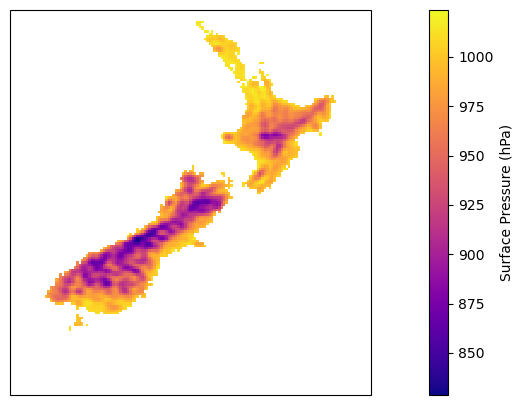

In [14]:
fig, ax = plt.subplots(figsize=(15, 5), **{'subplot_kw': {'projection': ccrs.PlateCarree()}})
mean_era5 = era5_ds[era5_var].mean(dim='time')
max_era5 = mean_era5.max().values
min_era5 = mean_era5.min().values
mean_era5.plot(ax=ax, 
                cmap=cmap, 
                cbar_kwargs={'label': 'Surface Pressure (hPa)'},
                vmin=min_era5, vmax=max_era5)
ax.set_extent([165, 180, -50, -34], crs=ccrs.PlateCarree())

In [22]:
fig, ax = plt.subplots(figsize=(15, 5), **{'subplot_kw': {'projection': ccrs.PlateCarree()}})
station_means = station_df.groupby(['latitude', 'longitude']).mean().reset_index()
station_means.plot.scatter(x='longitude', 
                           y='latitude',
                           c=station_means[station_var], 
                           cmap=cmap,
                           ax=ax,
                           vmin=min_era5, vmax=max_era5)
ax.coastlines()
ax.set_extent([165, 180, -50, -34], crs=ccrs.PlateCarree())

Error in callback <function _draw_all_if_interactive at 0x2aaae5c6a840> (for post_execute), with arguments args (),kwargs {}:


error: unpack requires a buffer of 4 bytes

error: unpack requires a buffer of 4 bytes

<Figure size 1500x500 with 2 Axes>

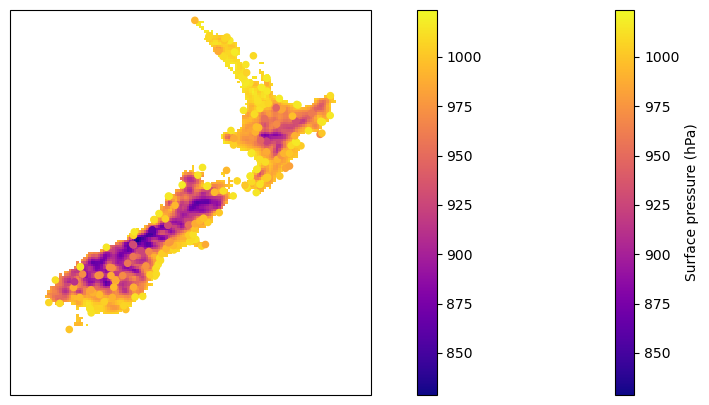

In [23]:
fig, ax = plt.subplots(figsize=(15, 5), **{'subplot_kw': {'projection': ccrs.PlateCarree()}})

mean_era5.plot(ax=ax, 
                cmap=cmap, 
                cbar_kwargs={'label': 'Surface pressure (hPa)'},
                vmin=min_era5, vmax=max_era5)
station_means.plot.scatter(x='longitude', 
                           y='latitude',
                           c=station_means[station_var], 
                           cmap=cmap,
                           ax=ax,
                           vmin=min_era5, vmax=max_era5)

ax.set_extent([165, 180, -50, -34], crs=ccrs.PlateCarree())


In [24]:
station_df

stn_lev_pres
time       station_name       latitude  longitude              
2020-01-01 AKAROA EWS         -43.80938 172.96574        1002.0
           AKITIO EWS         -40.57728 176.44889         981.0
           ALEXANDRA AWS      -45.21452 169.37549         983.8
           ALEXANDRA CWS      -45.25366 169.39205         993.2
           ALEXANDRA EWS      -45.25458 169.38448         993.7
...                                                         ...
2020-12-31 WHANGAREI EWS      -35.74440 174.32868        1019.2
           WHITIANGA AERO AWS -36.83237 175.67542        1020.5
           WHITIANGA EWS      -36.82817 175.67231        1020.3
           WINCHMORE 2 EWS    -43.78935 171.79032        1001.8
           WINDSOR EWS        -45.00829 170.82281        1012.4

[1640521 rows x 1 columns]

Text(0.5, 1.0, 'Station Pressure Histogram')

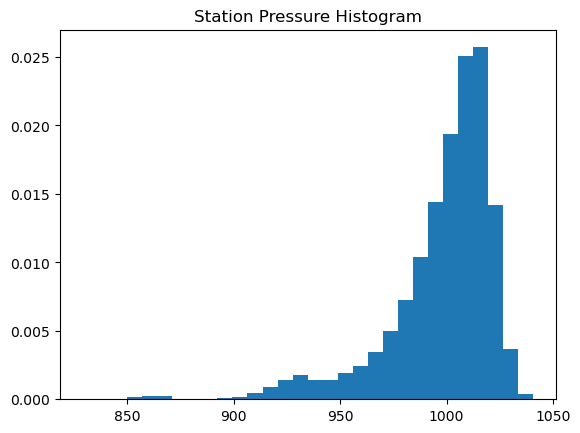

In [25]:
fig, ax = plt.subplots()
ax.hist(station_df['stn_lev_pres'].values, bins=30, density=True)
ax.set_title('Station Pressure Histogram')

In [26]:
from scipy.optimize import minimize
def custom_optimizer(func, x0, args=(), disp=0):
    res = minimize(func, x0, args, method="slsqp", options={"disp": disp})
    if res.success:
        return res.x
    raise RuntimeError('optimization routine failed')

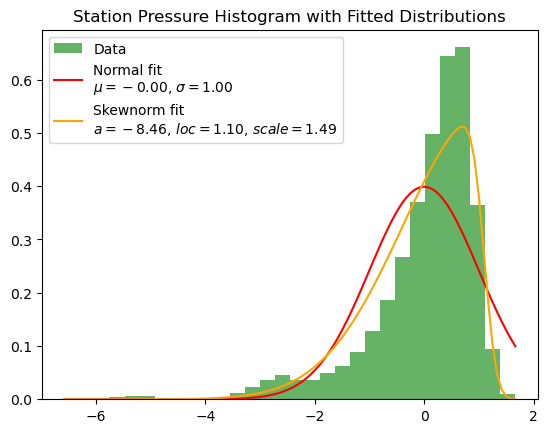

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm, lognorm, beta, skewnorm

# Get the pressure data (replace with your actual column name)
data = station_df['stn_lev_pres'].dropna().values
data = (data - np.mean(data)) / np.std(data)  # Standardize
# data = (data - min(data)) / (max(data) - min(data))  # Normalize to [0, 1]
# data = np.clip(data, 0.001, 0.999)  # Clip to avoid log(0) and log(1)

# Plot the histogram of the data
fig, ax = plt.subplots()
ax.hist(data, bins=30, density=True, alpha=0.6, color='g', label='Data')

# Fit and plot the Normal distribution
mu, std = norm.fit(data)
x = np.linspace(min(data), max(data), 100)
p_norm = norm.pdf(x, mu, std)
ax.plot(x, p_norm, 'r-', label=f'Normal fit\n$\\mu={mu:.2f}$, $\\sigma={std:.2f}$')

# # Fit and plot the Gamma distribution
# shape, loc, scale = gamma.fit(data, floc=0)
# p_gamma = gamma.pdf(x, shape, loc, scale)
# ax.plot(x, p_gamma, 'b-', label=f'Gamma fit\n$\\alpha={shape:.2f}$, $\\beta={scale:.2f}$')

# # Fit and plot the Log-Normal distribution
# shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(data, floc=0)
# p_lognorm = lognorm.pdf(x, shape_lognorm, loc_lognorm, scale_lognorm)
# ax.plot(x, p_lognorm, 'm-', label=f'Log-Normal fit\n$\\mu={shape_lognorm:.2f}$, $\\sigma={scale_lognorm:.2f}$')


#Skewnorm
a, loc, scale = skewnorm.fit(data)
p_skewnorm = skewnorm.pdf(x, a, loc, scale)
ax.plot(x, p_skewnorm, c='orange', label=f'Skewnorm fit\n$a={a:.2f}$, $loc={loc:.2f}$, $scale={scale:.2f}$')

# # Fit and plot the Beta distribution (normalize data to [0, 1] range)
# data_norm = (data - min(data)) / (max(data) - min(data))  # Normalize to [0, 1]
# alpha, beta_, loc_beta, scale_beta = beta.fit(data, floc=0, fscale=1)
# p_beta = beta.pdf(x, alpha, beta_, loc_beta, scale_beta)
# ax.plot(x, p_beta, 'm-', label=f'Beta fit\n$\\alpha={alpha:.2f}$, $\\beta={beta_:.2f}$')

# Customize plot
ax.set_title('Station Pressure Histogram with Fitted Distributions')
ax.legend()

plt.show()


/tmp/ipykernel_96364/2306431466.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "y-" (-> color='y'). The keyword argument will take precedence.
  ax.plot(x_norm, p_beta, 'y-', label=f'Beta fit\n$\\alpha={alpha:.2f}$, $\\beta={beta_:.2f}$',


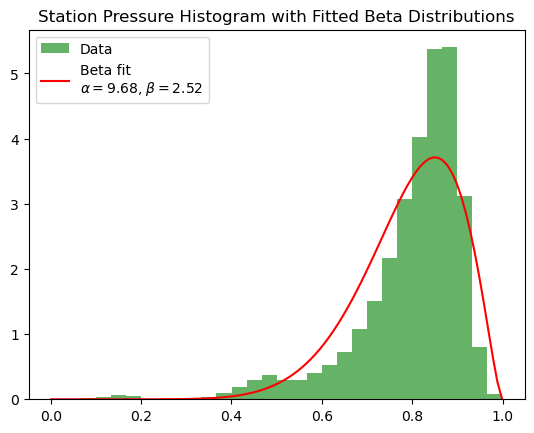

In [29]:
fig, ax = plt.subplots()



# Fit and plot the Beta distribution (normalize data to [0, 1] range)
data_norm = (data - min(data)) / (max(data) - min(data))  # Normalize to [0, 1]
data_norm = np.clip(data_norm, 0.001, 0.999)
x_norm = np.linspace(min(data_norm), max(data_norm), 100)

ax.hist(data_norm, bins=30, density=True, alpha=0.6, color='g', label='Data')

alpha, beta_, loc_beta, scale_beta = beta.fit(data_norm, floc=0, fscale=1)
p_beta = beta.pdf(x_norm, alpha, beta_, loc_beta, scale_beta)
ax.plot(x_norm, p_beta, 'y-', label=f'Beta fit\n$\\alpha={alpha:.2f}$, $\\beta={beta_:.2f}$',
        c='r')

ax.set_title('Station Pressure Histogram with Fitted Beta Distributions')
ax.legend()


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm, skewnorm, boxcox, yeojohnson

# Get the pressure data (replace with your actual column name)
data = station_df['stn_lev_pres'].values
data = (data - np.mean(data)) / np.std(data)  # Standardize
# data = (data - min(data)) / (max(data) - min(data))  # Normalize to [0, 1]
# data = np.clip(data, 0.001, 0.999)  # Clip to avoid log(0) and log(1)

# Apply Box-Cox transformation to the data (ensure data is positive)
# Box-Cox transformation requires strictly positive data, hence we shift if necessary
data_positive = data - min(data) + 1e-5  # Ensure positive data
data_transformed, lambda_ = boxcox(data_positive)

# Plot the histogram of the original and transformed data
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original data
ax[0].hist(data, bins=30, density=True, alpha=0.6, color='g', label='Original Data')

# Fit and plot the Normal distribution on the original data
mu, std = norm.fit(data)
x = np.linspace(min(data), max(data), 100)
p_norm = norm.pdf(x, mu, std)
ax[0].plot(x, p_norm, 'r-', label=f'Normal fit\n$\\mu={mu:.2f}$, $\\sigma={std:.2f}$')

# Transformed data
ax[1].hist(data_transformed, bins=30, density=True, alpha=0.6, color='g', label='Transformed Data')

# Fit and plot the Normal distribution on the transformed data
mu_transformed, std_transformed = norm.fit(data_transformed)
p_norm_transformed = norm.pdf(x, mu_transformed, std_transformed)
ax[1].plot(x, p_norm_transformed, 'r-', label=f'Normal fit\n$\\mu={mu_transformed:.2f}$, $\\sigma={std_transformed:.2f}$')

# Customize plot
ax[0].set_title('Original Data with Normal Fit')
ax[1].set_title('Box-Cox Transformed Data with Normal Fit')
ax[0].legend()
ax[1].legend()

plt.show()


/nesi/project/nesi03947/deepsensor/envs/deepsensor-patch/lib/python3.12/site-packages/scipy/special/_logsumexp.py:116: RuntimeWarning: invalid value encountered in exp
  tmp = np.exp(a - a_max)


BracketError: The algorithm terminated without finding a valid bracket. Consider trying different initial points.

In [ ]:
from scipy.stats import probplot

In [31]:
probplot(data, dist='norm', plot=plt)

NameError: name 'probplot' is not defined

In [33]:
probplot(data_transformed, dist='norm', plot=plt)

NameError: name 'probplot' is not defined

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm, norm

# Fit a skew normal distribution to your data
a, loc, scale = skewnorm.fit(data)

# Transform data using the CDF of the skew normal to a uniform distribution
uniform_data = skewnorm.cdf(data, a, loc, scale)

# Apply the inverse CDF of the normal distribution to get normal data
normal_data = norm.ppf(uniform_data)

# Plot the original, transformed, and the normal fit
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original data
ax[0].hist(data, bins=30, density=True, alpha=0.6, color='g', label='Original Data')
ax[0].set_title('Original Data')

# Transformed data
ax[1].hist(normal_data, bins=30, density=True, alpha=0.6, color='g', label='Transformed Data')
ax[1].set_title('Transformed Data (Normal)')

# Normal fit on the transformed data
mu, std = norm.fit(normal_data)
x = np.linspace(min(normal_data), max(normal_data), 100)
p_norm = norm.pdf(x, mu, std)
ax[2].hist(normal_data, bins=30, density=True, alpha=0.6, color='g', label='Transformed Data')
ax[2].plot(x, p_norm, 'r-', label=f'Normal fit\n$\\mu={mu:.2f}$, $\\sigma={std:.2f}$')
ax[2].set_title('Fit of Normal Distribution on Transformed Data')

# Show the plot
for a in ax:
    a.legend()

plt.show()


ValueError: The data contains non-finite values.

In [100]:
df = station_df.copy()
df = df.reset_index()
df['time'] = pd.to_datetime(df['time'])

# Choose a single station and a single time to plot
station_to_plot = df['station_name'].value_counts().idxmax()  # most common station
time_to_plot = df['time'].value_counts().idxmax()             # most common timestamp

# Prepare the three datasets
all_obs = df['stn_lev_pres'].dropna()

station_obs = df[df['station_name'] == station_to_plot]['stn_lev_pres'].dropna()

time_obs = df[df['time'] == time_to_plot]['stn_lev_pres'].dropna()


In [101]:
import seaborn as sns

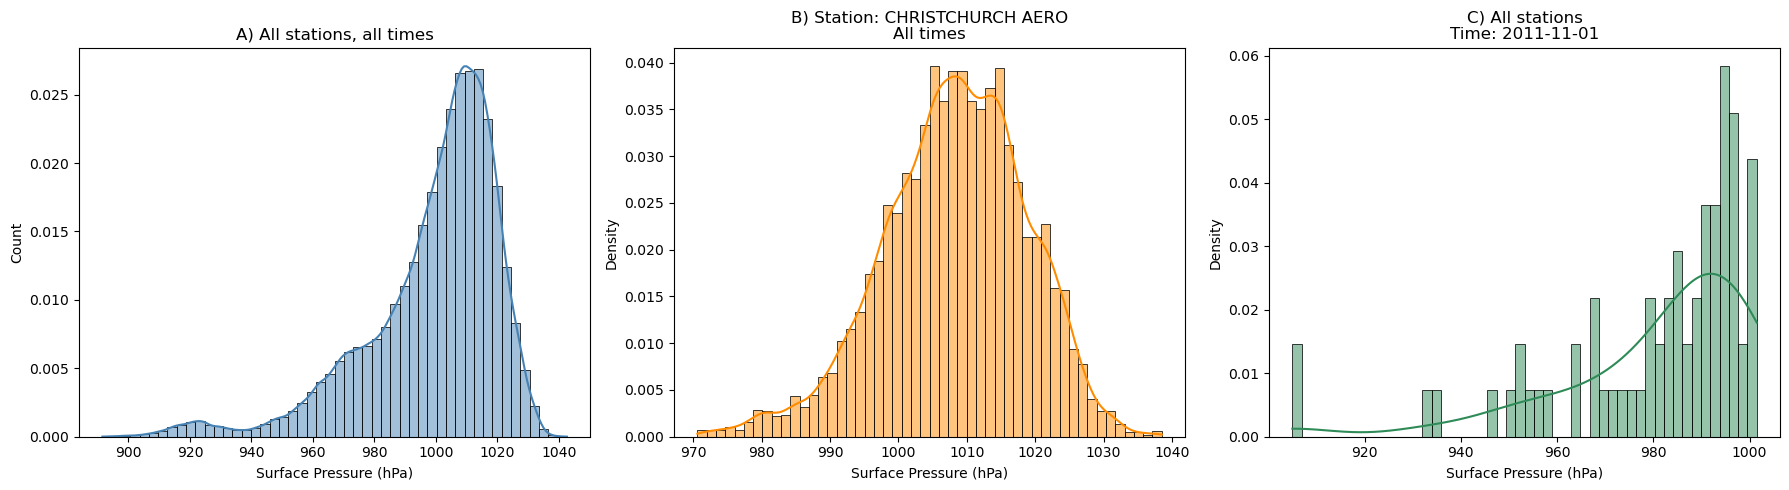

In [102]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# A) All stations, all times
sns.histplot(all_obs, bins=50, kde=True, ax=axs[0], color='steelblue', stat='density')
axs[0].set_title("A) All stations, all times")
axs[0].set_xlabel("Surface Pressure (hPa)")
axs[0].set_ylabel("Count")

# B) One station, all times
sns.histplot(station_obs, bins=50, kde=True, ax=axs[1], color='darkorange', stat='density')
axs[1].set_title(f"B) Station: {station_to_plot}\nAll times")
axs[1].set_xlabel("Surface Pressure (hPa)")

# C) All stations, one time
sns.histplot(time_obs, bins=50, kde=True, ax=axs[2], color='seagreen', stat='density')
axs[2].set_title(f"C) All stations\nTime: {time_to_plot.date()}")
axs[2].set_xlabel("Surface Pressure (hPa)")

plt.tight_layout()
plt.show()


In [103]:
station_df.dropna()

stn_lev_pres
time                station_name       latitude  longitude              
2009-01-01 00:00:00 WAIOURU AWS        -39.47200 175.68200         917.2
2009-01-01 01:00:00 WAIOURU AWS        -39.47200 175.68200         917.6
2009-01-01 02:00:00 WAIOURU AWS        -39.47200 175.68200         918.0
2009-01-01 03:00:00 WAIOURU AWS        -39.47200 175.68200         918.3
2009-01-01 04:00:00 WAIOURU AWS        -39.47200 175.68200         918.5
...                                                                  ...
2011-12-31 00:00:00 WHAKATANE AERO AWS -37.92478 176.91857        1007.8
                    WHANGANUI AERO AWS -39.96122 175.02581        1007.4
                    WHANGAPARAOA AWS   -36.60268 174.83458         993.4
                    WHANGAREI AERO AWS -35.77062 174.36285         999.7
                    WHITIANGA AERO AWS -36.83237 175.67542        1005.6

[1464132 rows x 1 columns]

In [95]:
df.dropna()['station_name'].unique()

array(['WAIOURU AWS', 'AUCKLAND AERO', 'MILFORD SOUND AWS',
       'MANAPOURI AERO AWS', 'TAUPO AERO AWS', 'QUEENSTOWN AERO AWS',
       'WANAKA AERO AWS', 'PUKAKI AERODROME AWS',
       'AUCKLAND  WHENUAPAI AWS', 'BLENHEIM AERO AWS',
       'BROTHERS ISLAND AWS', 'CAPE CAMPBELL AWS', 'CAPE TURNAGAIN AWS',
       'CASTLEPOINT AWS', 'CHRISTCHURCH AERO', 'DUNEDIN AERO AWS',
       'EAST TARATAHI AWS', 'FAIRLIE AWS', 'FAREWELL SPIT AWS',
       'GISBORNE AERO AWS', 'HAAST AWS', 'HAMILTON AERO AWS',
       'HAWERA AWS', 'HOKITIKA AERO AWS', 'INVERCARGILL AERO AWS',
       'KAIKOURA AWS', 'KERIKERI AERODROME AWS', 'LE BONS BAY AWS',
       'LEVIN AWS', 'LUMSDEN AWS', 'MAHIA AWS', 'MASTERTON AERO AWS',
       'MOKOHINAU ISLAND AWS', 'NAPIER AERO AWS', 'NELSON AERO AWS',
       'NEW PLYMOUTH AERO AWS', 'NGAWI AWS', 'NUGGET POINT AWS',
       'OAMARU AIRPORT AWS', 'OHAKEA AWS', 'PAEROA AWS',
       'PALMERSTON NORTH AERO AWS', 'PARAPARAUMU AERO AWS',
       'PORT TAHAROA AWS', 'PURERUA AWS', '

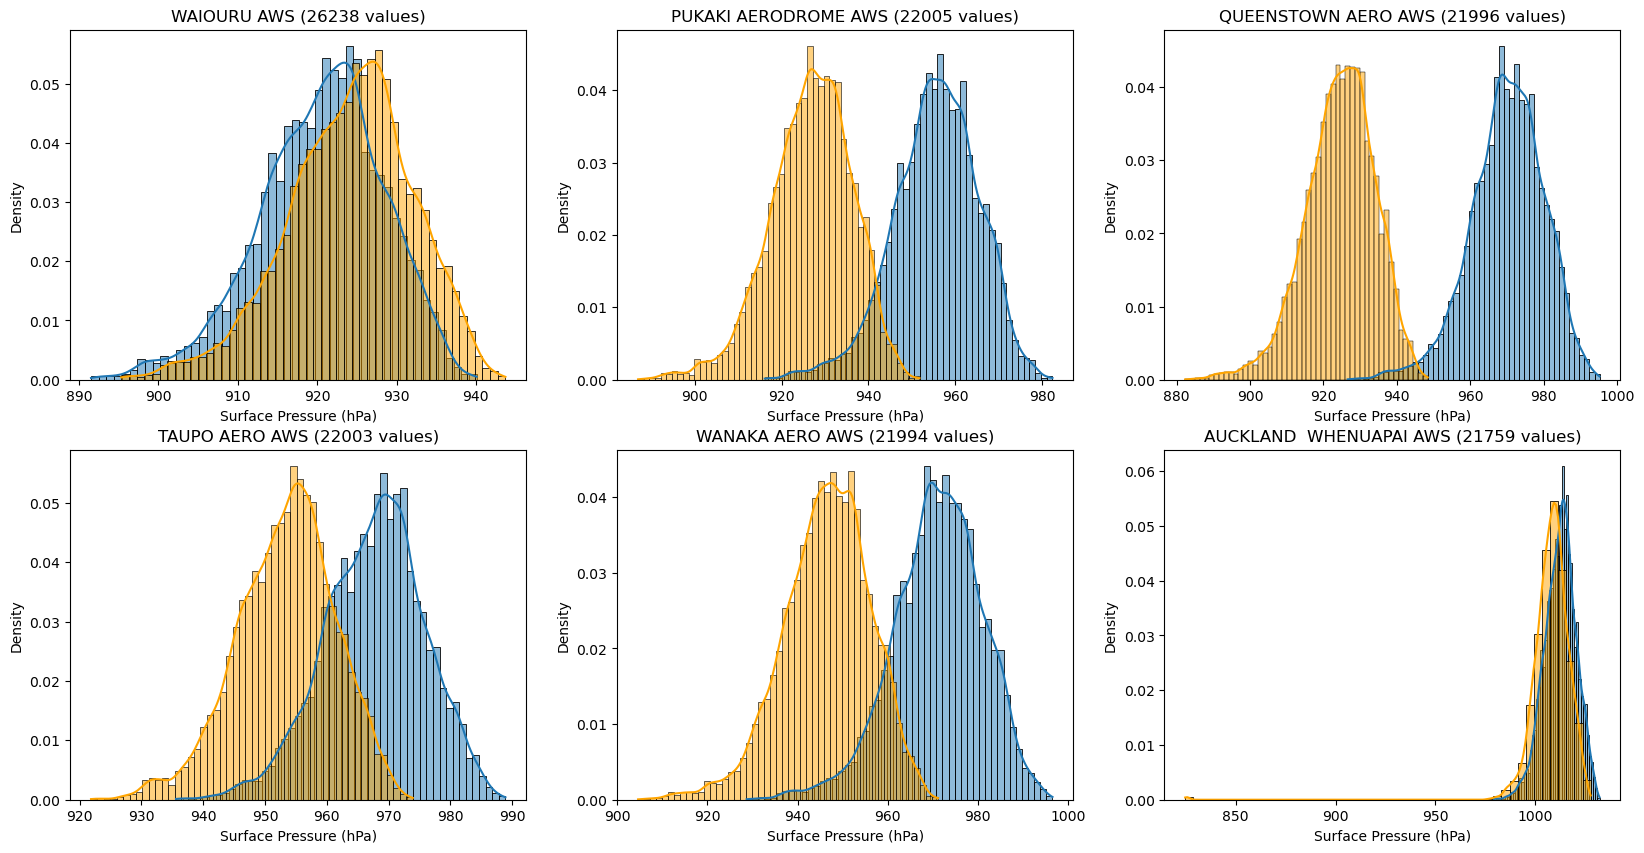

In [104]:
stations_to_plot = ['CAPE REINGA AWS', 'HICKS BAY AWS', 'MASTERTON EWS', 'CHRISTCHURCH AERO', 'WANAKA AERO AWS', 'MILFORD SOUND AWS']
# stations_to_plot = ['WHANGAREI AERO', "GISBORNE AERO", "WELLINGTON AERO", ]

stations_to_plot = df.dropna()['station_name'].unique()[:6]

fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharey=False)

for i, station in enumerate(stations_to_plot):
    station_vals = df[df['station_name'] == station]['stn_lev_pres'].dropna()
    num_vals = len(station_vals)

    sns.histplot(station_vals, bins=50, kde=True, ax=axs[i // 3, i % 3], stat='density')
    axs[i // 3, i % 3].set_title(f"{station} ({num_vals} values)")

    era5_values = era5_ds[era5_var].sel(latitude=df[df['station_name'] == station]['latitude'].unique()[0],
                                        longitude=df[df['station_name'] == station]['longitude'].unique()[0],
                                        method='nearest').values
    sns.histplot(era5_values, bins=50, kde=True, ax=axs[i // 3, i % 3], stat='density', color='orange')
    axs[i // 3, i % 3].set_xlabel("Surface Pressure (hPa)")
    

In [ ]:
station_df

stn_lev_pres
time       station_name       latitude  longitude              
2020-01-01 AKAROA EWS         -43.80938 172.96574        1002.0
           AKITIO EWS         -40.57728 176.44889         981.0
           ALEXANDRA AWS      -45.21452 169.37549         983.8
           ALEXANDRA CWS      -45.25366 169.39205         993.2
           ALEXANDRA EWS      -45.25458 169.38448         993.7
...                                                         ...
2020-12-31 WHANGAREI EWS      -35.74440 174.32868        1019.2
           WHITIANGA AERO AWS -36.83237 175.67542        1020.5
           WHITIANGA EWS      -36.82817 175.67231        1020.3
           WINCHMORE 2 EWS    -43.78935 171.79032        1001.8
           WINDSOR EWS        -45.00829 170.82281        1012.4

[1640521 rows x 1 columns]

In [105]:
import pandas as pd
import xarray as xr
from tqdm import tqdm

df = station_df_nonan.reset_index()
# Ensure time format is correct
df['time'] = pd.to_datetime(df['time'])

# Set up progress bar for apply
tqdm.pandas()

# Define lookup function
def lookup_era5(row):
    try:
        era5_value = era5_ds[era5_var].sel(
            time=row['time'], method='nearest'
        ).interp(
            latitude=row['latitude'],
            longitude=row['longitude']
        ).item()  # .item() to get scalar
        return era5_value
    except Exception as e:
        print(f"Failed at row: {row.name} with error: {e}")
        return np.nan

# Apply to all rows
df['era5_pres_interp'] = df.progress_apply(lookup_era5, axis=1)


  0%|          | 1479/1534130 [00:15<4:31:38, 94.04it/s] 


KeyboardInterrupt: 

In [106]:
times = xr.DataArray(df['time'].values,      dims=['points'])
lats  = xr.DataArray(df['latitude'].values,  dims=['points'])
lons  = xr.DataArray(df['longitude'].values, dims=['points'])

# vectorized interpolation
interp_da = era5_ds[era5_var].interp(
    time=times,
    latitude=lats,
    longitude=lons,
    method='linear'        # or ‘nearest’ if you don’t need bilinear
)

# pull out a NumPy array in one go
df['era5_pres_interp'] = interp_da.values

In [108]:
df.dropna(subset=['era5_pres_interp'])

,index,time,station_name,latitude,longitude,stn_lev_pres,year,era5_pres_interp
69998,69998,2009-01-01 00:00:00,WAIOURU AWS,-39.47200,175.68200,917.2,2009,919.049409
69999,69999,2009-01-01 01:00:00,WAIOURU AWS,-39.47200,175.68200,917.6,2009,919.437563
70000,70000,2009-01-01 02:00:00,WAIOURU AWS,-39.47200,175.68200,918.0,2009,919.895577
70001,70001,2009-01-01 03:00:00,WAIOURU AWS,-39.47200,175.68200,918.3,2009,920.270603
70002,70002,2009-01-01 04:00:00,WAIOURU AWS,-39.47200,175.68200,918.5,2009,920.501149
...,...,...,...,...,...,...,...,...
1534114,1534114,2011-12-31 00:00:00,TAUPO AERO AWS,-38.74252,176.08105,959.8,2011,945.075477
1534115,1534115,2011-12-31 00:00:00,TAUPO WXT AWS,-38.68400,176.07200,962.4,2011,947.639149
1534119,1534119,2011-12-31 00:00:00,WAIOURU AERO AWS,-39.44626,175.65786,914.4,2011,913.911970
1534120,1534120,2011-12-31 00:00:00,WAIOURU AWS,-39.47200,175.68200,913.8,2011,915.289115


In [137]:
import pickle
with open('/nesi/project/nesi03947/deepsensor/deepweather-downscaling/experiments/data_explore/by_variable/surface_pressure_bias_model_noelev.pkl', 'rb') as f:
    bias_model = pickle.load(f)

In [138]:
data = pd.read_csv('/nesi/project/nesi03947/deepsensor/deepweather-downscaling/experiments/data_explore/by_variable/surface_pressure_bias.csv')
data

,time,station_name,latitude,longitude,stn_lev_pres,elevation,era5_pres_interp,bias
0,2009-01-01 00:00:00,WAIOURU AWS,-39.47200,175.68200,917.2,820.0,919.049409,-1.849409
1,2009-01-01 01:00:00,WAIOURU AWS,-39.47200,175.68200,917.6,820.0,919.437563,-1.837563
2,2009-01-01 02:00:00,WAIOURU AWS,-39.47200,175.68200,918.0,820.0,919.895577,-1.895577
3,2009-01-01 03:00:00,WAIOURU AWS,-39.47200,175.68200,918.3,820.0,920.270603,-1.970603
4,2009-01-01 04:00:00,WAIOURU AWS,-39.47200,175.68200,918.5,820.0,920.501149,-2.001149
...,...,...,...,...,...,...,...,...
668772,2011-12-31 00:00:00,TAUPO AERO AWS,-38.74252,176.08105,959.8,402.0,945.075477,14.724523
668773,2011-12-31 00:00:00,TAUPO WXT AWS,-38.68400,176.07200,962.4,385.0,947.639149,14.760851
668774,2011-12-31 00:00:00,WAIOURU AERO AWS,-39.44626,175.65786,914.4,820.0,913.911970,0.488030
668775,2011-12-31 00:00:00,WAIOURU AWS,-39.47200,175.68200,913.8,820.0,915.289115,-1.489115


In [142]:
data['predicted'] = data['era5_pres_interp'] + bias_model.predict(data[['latitude', 'longitude']])

In [143]:
data

,time,station_name,latitude,longitude,stn_lev_pres,elevation,era5_pres_interp,bias,predicted
0,2009-01-01 00:00:00,WAIOURU AWS,-39.47200,175.68200,917.2,820.0,919.049409,-1.849409,917.365665
1,2009-01-01 01:00:00,WAIOURU AWS,-39.47200,175.68200,917.6,820.0,919.437563,-1.837563,917.753819
2,2009-01-01 02:00:00,WAIOURU AWS,-39.47200,175.68200,918.0,820.0,919.895577,-1.895577,918.211834
3,2009-01-01 03:00:00,WAIOURU AWS,-39.47200,175.68200,918.3,820.0,920.270603,-1.970603,918.586859
4,2009-01-01 04:00:00,WAIOURU AWS,-39.47200,175.68200,918.5,820.0,920.501149,-2.001149,918.817406
...,...,...,...,...,...,...,...,...,...
668772,2011-12-31 00:00:00,TAUPO AERO AWS,-38.74252,176.08105,959.8,402.0,945.075477,14.724523,960.583665
668773,2011-12-31 00:00:00,TAUPO WXT AWS,-38.68400,176.07200,962.4,385.0,947.639149,14.760851,963.056721
668774,2011-12-31 00:00:00,WAIOURU AERO AWS,-39.44626,175.65786,914.4,820.0,913.911970,0.488030,914.146518
668775,2011-12-31 00:00:00,WAIOURU AWS,-39.47200,175.68200,913.8,820.0,915.289115,-1.489115,913.605372


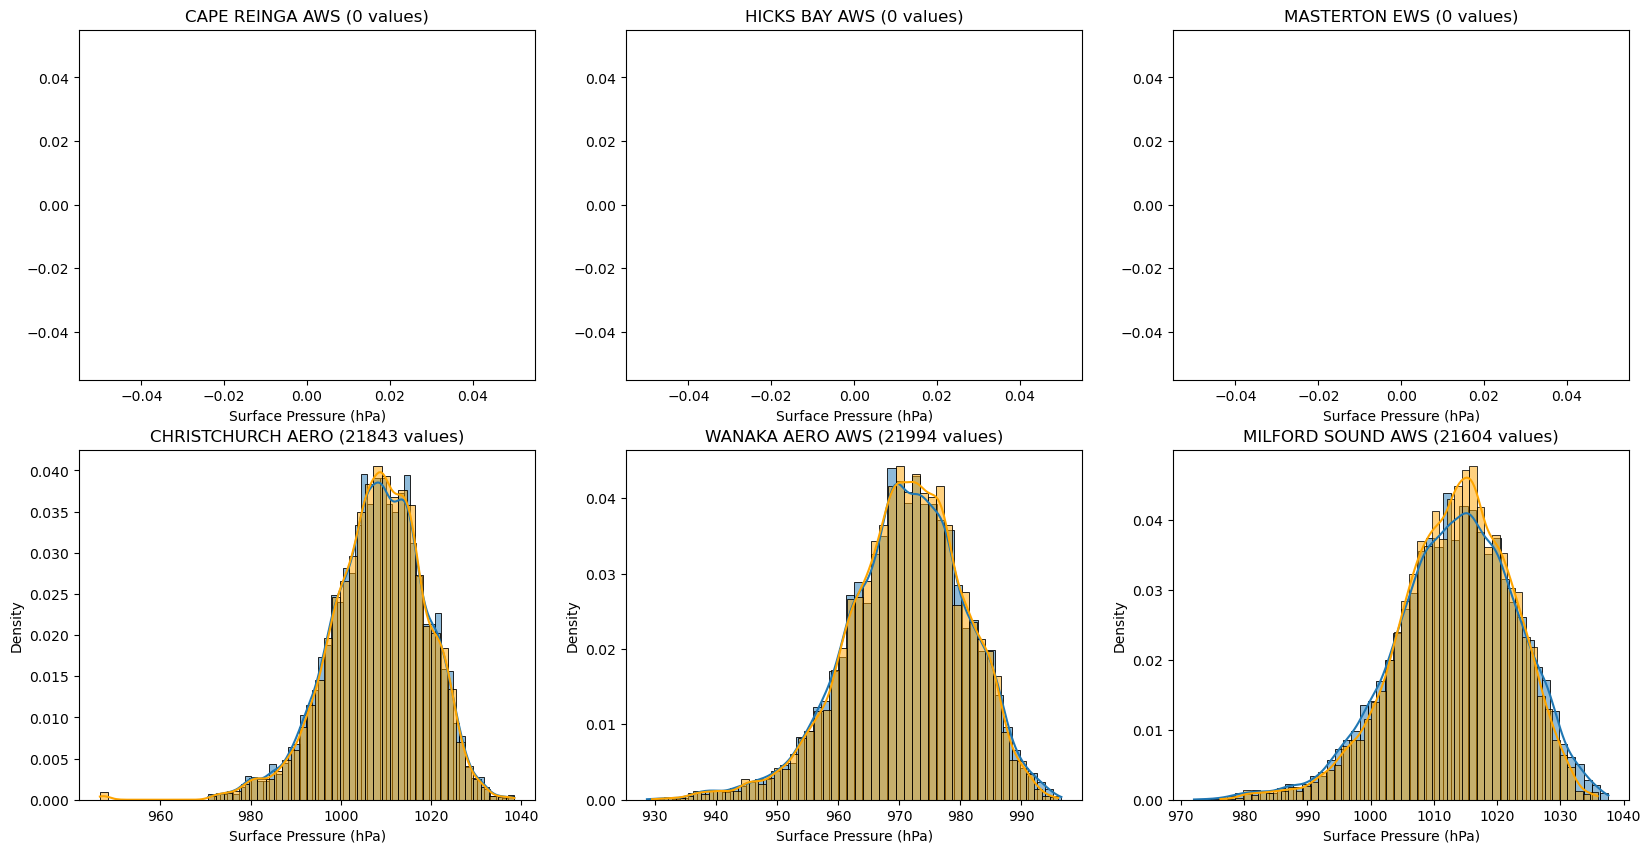

In [144]:
stations_to_plot = ['CAPE REINGA AWS', 'HICKS BAY AWS', 'MASTERTON EWS', 'CHRISTCHURCH AERO', 'WANAKA AERO AWS', 'MILFORD SOUND AWS']
# stations_to_plot = ['WHANGAREI AERO', "GISBORNE AERO", "WELLINGTON AERO", ]

# stations_to_plot = df.dropna()['station_name'].unique()[:6]

fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharey=False)

for i, station in enumerate(stations_to_plot):
    station_vals = data[data['station_name'] == station]['stn_lev_pres'].dropna()
    num_vals = len(station_vals)

    sns.histplot(station_vals, bins=50, kde=True, ax=axs[i // 3, i % 3], stat='density')
    axs[i // 3, i % 3].set_title(f"{station} ({num_vals} values)")

    era5_values =  data[data['station_name'] == station]['predicted'].dropna()

    sns.histplot(era5_values, bins=50, kde=True, ax=axs[i // 3, i % 3], stat='density', color='orange')
    axs[i // 3, i % 3].set_xlabel("Surface Pressure (hPa)")
    

In [145]:
era5_ds

<xarray.Dataset>
Dimensions:    (longitude: 221, latitude: 191, time: 26280)
Coordinates:
  * longitude  (longitude) float32 161.0 161.1 161.2 161.3 ... 182.8 182.9 183.0
  * latitude   (latitude) float32 -31.0 -31.1 -31.2 -31.3 ... -49.8 -49.9 -50.0
  * time       (time) datetime64[ns] 2009-01-01 ... 2011-12-31T23:00:00
Data variables:
    sp         (time, latitude, longitude) float32 nan nan nan ... nan nan nan
Attributes:
    Conventions:  CF-1.6
    history:      2024-02-10 04:30:20 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [155]:
lats = era5_ds['latitude'].values     # 1D, shape (n_lat,)
lons = era5_ds['longitude'].values 
LAT2D, LON2D = np.meshgrid(lats, lons, indexing='ij')

flat_lat   = LAT2D.ravel()
flat_lon   = LON2D.ravel()

X_pred = np.vstack([flat_lat, flat_lon]).T
y_pred_flat = bias_model.predict(X_pred)

/nesi/project/nesi03947/deepsensor/envs/deepsensor-patch/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [157]:
pred_2d = y_pred_flat.reshape(len(lats), len(lons))

bias_field = xr.DataArray(
    pred_2d,
    dims=('latitude', 'longitude'),
    coords={
        'latitude': lats,
        'longitude': lons
    },
    name='predicted_bias'
)

ds_with_bias = era5_ds.assign(predicted_bias=bias_field)



In [159]:
era5_ds = era5_ds.assign(predicted_bias=bias_field)
era5_ds['sp_orig'] = era5_ds[era5_var]
era5_ds[era5_var] = era5_ds[era5_var] + era5_ds['predicted_bias']
era5_ds

<xarray.Dataset>
Dimensions:         (longitude: 221, latitude: 191, time: 26280)
Coordinates:
  * longitude       (longitude) float32 161.0 161.1 161.2 ... 182.8 182.9 183.0
  * latitude        (latitude) float32 -31.0 -31.1 -31.2 ... -49.8 -49.9 -50.0
  * time            (time) datetime64[ns] 2009-01-01 ... 2011-12-31T23:00:00
Data variables:
    sp              (time, latitude, longitude) float64 nan nan nan ... nan nan
    predicted_bias  (latitude, longitude) float64 96.09 96.09 ... 24.82 24.82
    sp_orig         (time, latitude, longitude) float32 nan nan nan ... nan nan
Attributes:
    Conventions:  CF-1.6
    history:      2024-02-10 04:30:20 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...